In [1]:
using Revise
using MajoranaPropagation
using PauliPropagation

using Plots 
using LaTeXStrings
using TimerOutputs
using ProgressMeter


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


Simulate the dynamics of the spinful Hubbard model on a 1D chain of $N$ spinful sites. The Hamiltonian is
$$\hat{H}=-t \sum_{i, \sigma=\{\uparrow, \downarrow\}}\left(\hat{c}_{i, \sigma}^{\dagger} \hat{c}_{i+1, \sigma}+\hat{c}_{i+1, \sigma}^{\dagger} \hat{c}_{i, \sigma}\right)+U \sum_i \hat{n}_{i \uparrow} \hat{n}_{i \downarrow}$$

In [2]:
N_spinful_sites = 20
t = 1.
U = 1.5

n_layers = 10
dt = 0.07

0.07

Get 1D connectivity, and create the circtuit for implementing a single layer of first order Trotterization.

In [3]:
topo = bricklayertopology(N_spinful_sites)

circ_single = []
thetas_single = []

#up hoppings 
for (i, j) in topo
    push!(circ_single, FermionicGate(:hopup, [i, j]))
    push!(thetas_single, -t * dt)
end

#down hoppings 
for (i, j) in topo
    push!(circ_single, FermionicGate(:hopdn, [i, j]))
    push!(thetas_single, -t * dt)
end

#on-site repulsion 
for i = 1:N_spinful_sites
    push!(circ_single, FermionicGate(:nupndn, i))
    push!(thetas_single, U * dt)
end

#### Set the truncations
1. `min_abs_coeff`: PP coefficient truncation
2. `max_singles`: number of unpaired Majoranas, namely the number of indices $i$ where only one of $\gamma_i$, $\gamma'_i$ are non-zero

In [4]:
min_abs_coeff = 1.e-8
max_unpaired = 10

10

Set the inital state as the checkerboard state $\ket{\uparrow\downarrow\cdots\uparrow\downarrow}$

In [5]:
#initial state 
initial_state_label = "Checkerboard"

create_up_part_at = 1:2:N_spinful_sites
create_down_part_at = 2:2:N_spinful_sites

fock_state = fockstate(create_up_part_at, create_down_part_at)

fockstate([1, 4, 5, 8, 9, 12, 13, 16, 17, 20, 21, 24, 25, 28, 29, 32, 33, 36, 37, 40], true)

Backpropagate $n_{2,\uparrow}$, the up density on site 2

In [6]:
to = TimerOutput()

site_index = 3
obs = MajoranaSum(N_spinful_sites, :nup, site_index)

@show obs 

res = zeros(n_layers+1)
res[1] = overlapwithfock(obs, fock_state)

for k=1:n_layers
    @timeit to "propagate" propagate!(circ_single, obs, thetas_single, min_abs_coeff=min_abs_coeff, max_unpaired=max_unpaired)
    @timeit to "evaluate" res[k+1] = overlapwithfock(obs, fock_state)
end 

to

obs = MajoranaSum with 2 term(s):
    0.5 * 00000000000000000000000000000000000000000000000000000000000000000000000000000000
    0.5 * 00000000110000000000000000000000000000000000000000000000000000000000000000000000


──────────────────────────────────────────────────────────────────────
                             Time                    Allocations      
                    ───────────────────────   ────────────────────────
 Tot / % measured:       2.54s /  82.6%            264MiB /  60.2%    

Section     ncalls     time    %tot     avg     alloc    %tot      avg
──────────────────────────────────────────────────────────────────────
propagate       10    2.09s   99.8%   209ms    159MiB  100.0%  15.9MiB
evaluate        10   5.04ms    0.2%   504μs   40.8KiB    0.0%  4.08KiB
──────────────────────────────────────────────────────────────────────

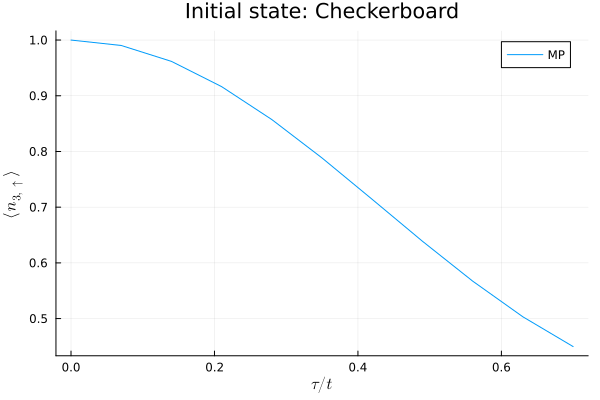

In [7]:
p = plot(dt*(0:n_layers)./ t, res, label="MP", xlabel=L"\tau/t", ylabel=L"\langle n_{%$site_index,\uparrow}\rangle", title = "Initial state: " * initial_state_label)
display(p)

Let's now consider the more complex observable $O = n_{2, \uparrow}n_{6,\downarrow}n_{10,\uparrow}$

In [8]:
min_abs_coeff = 1.e-5
max_unpaired = 8

to = TimerOutput()

site_index = 2
obs = MajoranaSum(N_spinful_sites, :nup, site_index) * MajoranaSum(N_spinful_sites, :ndn, site_index + 4) * MajoranaSum(N_spinful_sites, :nup, site_index + 8)

@show obs 

res = zeros(n_layers+1)
res[1] = overlapwithfock(obs, fock_state)

for k=1:n_layers
    @timeit to "propagate" propagate!(circ_single, obs, thetas_single, min_abs_coeff=min_abs_coeff, max_unpaired=max_unpaired)
    @timeit to "evaluate" res[k+1] = overlapwithfock(obs, fock_state)
    @show k, length(obs)
end 

@show res 

to

obs = MajoranaSum with 8 term(s):
    0.125 * 00000000000000000000000000000000000000000000000000000000000000000000000000000000
    0.125 * 00000000000000000000000000000000000011000000000000000000000000000000000000000000
    0.125 * 00000000000000000000001100000000000000000000000000000000000000000000000000000000
    -0.125 * 00001100000000000000001100000000000011000000000000000000000000000000000000000000
    -0.125 * 00001100000000000000000000000000000011000000000000000000000000000000000000000000
    -0.125 * 00000000000000000000001100000000000011000000000000000000000000000000000000000000
    -0.125 * 00001100000000000000001100000000000000000000000000000000000000000000000000000000
    0.125 * 00001100000000000000000000000000000000000000000000000000000000000000000000000000
(k, length(obs)) = (1, 624)
(k, length(obs)) = (2, 2468)
(k, length(obs)) = (3, 6876)
(k, length(obs)) = (4, 12875)
(k, length(obs)) = (5, 26894)
(k, length(obs)) = (6, 50777)
(k, length(obs)) = (7, 88013)
(k, length(o

──────────────────────────────────────────────────────────────────────
                             Time                    Allocations      
                    ───────────────────────   ────────────────────────
 Tot / % measured:       3.37s /  94.9%            215MiB /  79.0%    

Section     ncalls     time    %tot     avg     alloc    %tot      avg
──────────────────────────────────────────────────────────────────────
propagate       10    3.19s   99.8%   319ms    170MiB  100.0%  17.0MiB
evaluate        10   7.49ms    0.2%   749μs   40.8KiB    0.0%  4.08KiB
──────────────────────────────────────────────────────────────────────